<a href="https://colab.research.google.com/github/ulya1202/NLP/blob/main/Hugging_Face_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image, ImageDraw
import requests

In [ ]:
from transformers import AutoModel, AutoTokenizer, pipeline

Hugging Face Nədir və Nə İşə Yarayır? 🤗
Sadə dildə desək, Hugging Face süni intellekt (AI) və maşın öyrənməsi (Machine Learning) üçün bir növ "GitHub"dır. Bu platforma, tərtibatçılar, tədqiqatçılar və həvəskarlar üçün nəzərdə tutulub və bir neçə əsas məqsədə xidmət edir:

Modellərin Mərkəzi (Model Hub): Dünyanın hər yerindən tərtibatçılar öz hazırladıqları süni intellekt modellərini (məsələn, mətn tərcüməsi, şəkil tanıma, səs analizi üçün modellər) bura yükləyirlər. Siz də bu hazır modelləri pulsuz şəkildə endirib öz layihələrinizdə istifadə edə bilərsiniz. Bu, hər dəfə "Amerikanı yenidən kəşf etməyə" ehtiyac qalmaması deməkdir.

Verilənlər Bazasının Mərkəzi (Dataset Hub): Süni intellekt modellərini "öyrətmək" üçün çoxlu məlumata (verilənlər bazasına) ehtiyac var. Hugging Face, müxtəlif mövzularda (məsələn, minlərlə kitab mətni, şəkillər, səs yazıları) böyük verilənlər bazalarını bir araya gətirir.

Alətlər və Kitabxanalar (Tools & Libraries): Hugging Face-in ən məşhur aləti transformers adlı kitabxanadır. Bu kitabxana, mürəkkəb süni intellekt modellərini cəmi bir neçə sətir kodla istifadə etməyi çox asanlaşdırır. Məhz bu kitabxana sayəsində süni intellektlə işləmək daha əlçatan olub.

####cheet sheets
- dataset object --> [Dataset](https://https://g.co/gemini/share/829f15062169)
- datasetdict object-->[DatasetDict](https://https://g.co/gemini/share/bd11388f92f2)
- classlabel object--> [ClassLabel](https://https://g.co/gemini/share/1a8f55402563)

- Auto.. --> [model, tokenizer](https://g.co/gemini/share/9aedcfb65624)
-EDA --> [EDA](https://g.co/gemini/share/7bfba931b9d3)
- Feature Extraction --[extract CLS token and classify](https://g.co/gemini/share/93a2cfd1c128)




# Extra Functions

In [ ]:
def show_img(img_url, results):
  response = requests.get(image_url, stream=True)
  image = Image.open(response.raw)
  draw = ImageDraw.Draw(image)
  # Draw bounding boxes for each detected object
  for obj in results:
      box = obj['box']
      label = obj['label']
      score = obj['score']

      # Draw the rectangle
      draw.rectangle([box['xmin'], box['ymin'], box['xmax'], box['ymax']], outline="red", width=3)

      # Add the label and score
      text = f"{label}: {score:.2f}"
      text_x = box['xmin']
      text_y = box['ymin'] - 10 # Adjust y position to be above the box

      # Add text with a background for better visibility
      text_bbox = draw.textbbox((text_x, text_y), text)
      draw.rectangle(text_bbox, fill="red")
      draw.text((text_x, text_y), text, fill="white")


  # Display the image with bounding boxes
  display(image)


# Pipeline

## 📦 Pipeline nədir?

`pipeline()` — Hugging Face `transformers` kitabxanasında model, tokenizer və pre/post-process addımlarını birləşdirən sadə API-dir.

**İş prinsipi:**
1. Task müəyyən edilir (məs. `sentiment-analysis`, `text-generation`, `ner` və s.).
2. Hugging Face həmin task üçün default model və config seçir (istəsən dəyişdirə bilərsən).
3. Tokenizer input-u tokenlərə çevirir.
4. Model (PyTorch / TensorFlow) tensorlara işləyir.
5. Post-processing edilir (məs. logits → softmax → label).
6. Nəticə `dict` formatında qaytarılır.
**💡 Burada pipeline-->  tokenizer-i yükləyir,(inputu tokenize edir) -->modeli yükləyir(config-i oxuyur)(tokenleri modele oturur) --> nəticəni çıxarır. bu neticeler raw(probabiltyler) olur, onlari postprocces edir ve geri qaytarir**
__
Postprocessing nədir?
Məsələn: "Modeldən çıxan nəticələr (logits) hamısı ehtimal dəyərləri deyil, onları softmax funksiyası ilə ehtimallara çeviririk, sonra ən uyğun etiketi (label) tapırıq."

| 😊 Üstünlüklər                                              | ⚠️ Çatışmazlıqlar                                         |
| ----------------------------------------------------------- | --------------------------------------------------------- |
| 🚀 Sürətli başlama (bir neçə sətir kod)                     | ⚙️ Az çeviklik — xüsusi preprocessing çətin ola bilər     |
| 📦 Model + tokenizer + preprocessing avtomatik              | 📉 Çox böyük modellərdə performans problemi yarana bilər  |
| 🔄 Müxtəlif tapşırıqlar üçün hazır interfeys (NLP, CV, ASR) | 🧩 Xüsusi loss funksiyası və ya training üçün uyğun deyil |
| 🌐 Hugging Face Hub ilə asan inteqrasiya                    | 📜 Bəzi modellərdə sənəd zəif ola bilər                   |


## Speech-to-text

In [ ]:
# from transformers import pipeline

# asr = pipeline(
#     "automatic-speech-recognition",
#     model="nijatzeynalov/wav2vec2-large-mms-1b-azerbaijani-common_voice15.0",
#     device=0  # GPU varsa; CPU üçün device=-1 yaz
# )

# result = asr("/content/drive/MyDrive/audio [vocals].mp3")
# print(result["text"])


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

## Sentiment-analysis pipeline

In [ ]:
sentiment_pipeline = pipeline("sentiment-analysis") #isteye uygun modelin adini da qeyd ede bilersiz

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


In [ ]:
data = ["I love how simple and powerful this is!"]
result = sentiment_pipeline(data)
print(result)

[{'label': 'POSITIVE', 'score': 0.9998843669891357}]


In [ ]:
# Modeli adı ilə birlikdə təyin edirik
specific_model_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Sınaq
text = ["This is a fantastic opportunity."]
result = specific_model_pipeline(text)
print(result)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9998841285705566}]


##Text generation pipeline

In [ ]:
# 3. Mətn yaratma üçün pipeline yaradın
generator = pipeline("text-generation")

# 4. Cümləni tamamlayın
incomplete_sentence = "The future of Artificial Intelligence is" # (Model ingiliscə olduğu üçün cümləni ingiliscə verin)
generated_text = generator(incomplete_sentence, max_length=50, num_return_sequences=1)
#max_lenght--> cumle uzunluqu , num_return_sequences yeni 1 cumle
# max_length — nəticə mətni maksimum neçə token ola bilər.
# num_return_sequences — neçə fərqli tamamlanma yaradılsın.

# 5. Nəticəni göstərin
print(generated_text)

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'The future of Artificial Intelligence is uncertain. However, we are getting close to the point where artificial intelligence can be used for many things, including medicine, health care, and business. We are also coming into the second half of the 20th century with the advent of autonomous vehicles, and with the advent of artificial intelligence. At least the most recent data have shown that the benefits of human and robotic driving are being realized now.\n\nThis article is about the future of artificial intelligence, not AI.\n\nThis article is about the future of artificial intelligence, not AI.\n\nThis article is about the future of artificial intelligence, not AI.'}]


## Zero Shot Classifiaction

In [ ]:
#Bu, modelin əvvəlcədən təlim görmədiyi etiketlərə (label) görə mətni təsnif etməsidir. Siz ona sadəcə mümkün variantları (candidate_labels) verirsiniz,
#o isə mətnin hansına daha çox uyğun gəldiyini tapır.
# birbasha oyrenir ,  (label olmur) oyrene biler, one shotda ise bir numune gosterik
#data yoxdursa istifade etmke  olar
#(diger halda tovsiye edilmir zero shot)

classifier=pipeline('zero-shot-classification')#hansi model isteyrik
classifier('I realy love  taht country',
           candidate_labels=['travel', 'education','technology']) # bu labelrden hasni olsun

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


{'sequence': 'I realy love  taht country',
 'labels': ['travel', 'education', 'technology'],
 'scores': [0.8110681176185608, 0.09454482793807983, 0.09438704699277878]}

##📝 Tasks for pipeline:

### 1)Tapşırıq 1 — Sadə sentiment analizi

In [ ]:
# Hazır sentiment-analysis pipeline istifadə et
# Azərbaycan dilində bir neçə cümlə yoxla

###2)"summarization" pipline duzeldin bu metnin summarizini yaradin:


In [ ]:
long_text = """
Artificial intelligence (AI) is rapidly changing various sectors of the economy and society.
In healthcare, AI algorithms are being used to diagnose diseases more accurately and to personalize treatment plans for patients.
In the financial industry, AI helps in fraud detection and algorithmic trading.
The transportation sector is also being revolutionized with the development of self-driving cars, which rely heavily on AI for navigation and safety.
While the potential benefits are immense, there are also significant challenges to address, such as ethical considerations, job displacement, and data privacy concerns.
Ensuring that AI is developed and used responsibly is one of the most critical tasks for technologists and policymakers today.
"""

In [ ]:
#pipeline yaradırıq
## Xülasəni yaradırıq (minimum 25, maksimum 50 söz)

###3)Object detection

Tapşırıq 2: Şəkildə Obyektlərin Tapılması (Object Detection)
Məqsəd: pipeline istifadə edərək bir şəklin içindəki fərqli obyektləri (insan, maşın, top və s.) tapmaq və onların yerini koordinatlarla müəyyən etmək. Bu, kompüter görməsi (Computer Vision) sahəsinə aiddir.

Addımlar:

Bu tapşırıq üçün əlavə bir kitabxana – Pillow (PIL) – lazım olacaq. Onu da quraşdırın: !pip install Pillow.

pipeline-ı import edin.

"object-detection" tapşırığı üçün bir pipeline yaradın. Standart model kifayət edəcək.

İnternetdən bir şəkil URL-i tapın. Məsələn, şəhər küçəsində bir neçə maşın və insanın olduğu bir şəkil.

Həmin URL-i pipeline-a ötürərək şəkildəki obyektləri tapın.

Nəticələri çap edin. Hər bir tapılan obyekt üçün onun adı (label), əminlik dərəcəsi (score) və şəkildəki yerini göstərən çərçivənin (box) koordinatları göstəriləcək.

In [ ]:

# 1. Pillow kitabxanası transformers ilə birlikdə adətən quraşdırılır,
#    əgər xəta versə, !pip install Pillow yazın.

# 3. Obyekt tapmaq üçün pipeline yaradırıq

# 4. Şəkil URL-i
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"

# 5. Obyektləri tapırıq

# 6. Nəticələri səliqəli şəkildə çap edirik

#isteye ugun bu funksiya ile vizuallashdira bilersiz : show_img(img_url, results)

### 4)Hugging Faceden bir modeli pipeline ile yoxla

# Models/Tokenizers

In [ ]:
# Hər modelin öz sinfi var, məsələn, BertModel, GPT2Model və s.
# Bu modellərin hansı versiyasını yükləmək istəsək, from_pretrained('model_adı') yazırıq.
# Bu zaman Hugging Face model adı əsasında modelin öncədən təlim görmüş çəkilərini (weights) və konfiqurasiyasını yükləyir.
# Beləliklə, modeli dərhal işlətməyə başlaya bilərik.

In [ ]:
# Problem nədir?
# Hər modelin öz sinfi var, istifadə edərkən həmin sinifi çağırmalısan (məsələn, BertModel, RobertaModel, GPT2Model və s.).
# Kodda model adı dəyişəndə, import və obyekt yaratma kodu da dəyişməlidir.
# Bu, dinamik kod yazmağı çətinləşdirir, məsələn, birdən çox model üzərində işləyərkən.

### BERTModel class

In [ ]:
from transformers import BertModel, BertTokenizer
model_name = "bert-base-uncased"

In [ ]:
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
text = "Salam dünya!"
inputs = tokenizer(text, return_tensors="pt")

In [ ]:
outputs = model(**inputs)
print(outputs.last_hidden_state.shape)#logits(probabilities)

torch.Size([1, 7, 768])


In [ ]:
outputs

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[-0.4424,  0.1784, -0.3208,  ..., -0.3955,  0.0716,  0.3453],
         [ 0.1450,  0.3475, -0.4512,  ..., -0.2239, -0.4091, -0.2240],
         [-0.5743, -0.0355, -0.4764,  ..., -0.1270, -0.0581, -0.0491],
         ...,
         [ 0.1153, -0.1868, -0.5481,  ..., -0.6323,  0.1252,  0.4370],
         [-0.6968, -0.3866, -1.0387,  ...,  0.6118, -0.0712, -0.1178],
         [ 0.7540,  0.0993, -0.5588,  ...,  0.2783, -0.6731, -0.2194]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[-0.8636, -0.3910, -0.7541,  0.7882,  0.3685, -0.1038,  0.9089,  0.3229,
         -0.6050, -1.0000, -0.3652,  0.8025,  0.9703,  0.5488,  0.9144, -0.7545,
         -0.3388, -0.6433,  0.4776, -0.6218,  0.6239,  0.9999,  0.0746,  0.2625,
          0.4469,  0.9462, -0.7720,  0.9071,  0.9370,  0.6315, -0.7152,  0.1443,
         -0.9729, -0.2278, -0.8449, -0.9889,  0.3613, -0.6966, -0.0568,  0.0102,
         -0.8604,  0.2284,  0.99

### GPT2Model class

In [ ]:
from transformers import GPT2Model, GPT2Tokenizer

model_name = "gpt2"

tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2Model.from_pretrained(model_name)

text = "Hello world!"
inputs = tokenizer(text, return_tensors="pt")

outputs = model(**inputs)
print(outputs.last_hidden_state.shape)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

torch.Size([1, 3, 768])


### Auto..

#### AutoModel

AutoModel nədir?
Hugging Face-də AutoModel “universal adapter” kimidir.

Hər bir NLP modeli fərqli class-da olur (məsələn, BertModel, RobertaModel, GPT2Model və s.).

Əgər sən modelin hansı ailəyə aid olduğunu bilmirsənsə, amma **model_name** bilirsənsə, AutoModel sənin yerinə uyğun class-ı avtomatik seçir.

Yəni: Sənə lazım deyil “bu BERT-dir, yoxsa GPT-dir” bilmək — sadəcə modelin adını verirsən, o özü uyğun obyekt yaradır.

Əsas növlər
AutoModel tək deyil, müxtəlif versiyaları var:

AutoModel → sadəcə encoder (transformer backbone).

✅**AutoModel sadəcə backbone yükləyir, amma bəzi tapşırıqlar üçün “baş” (head) əlavə edən versiyalarından istifadə etməlisən.**

AutoModelForSequenceClassification → təsnifat üçün hazır head ilə.

AutoModelForTokenClassification → token səviyyəsində təsnifat (NER və s.).

AutoModelForCausalLM → mətn generasiyası üçün (GPT tipli).

AutoModelForMaskedLM → Masked Language Model (BERT tipli mask prediction).

AutoModelForSpeechSeq2Seq → Whisper kimi danışıqdan mətinə çevirən modellər.

In [ ]:
from transformers import AutoTokenizer, AutoModel

model_name = "bert-base-uncased"  # və ya "gpt2", "roberta-base" və s.

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

In [ ]:
inputs = tokenizer("Salam dünya!", return_tensors="pt")
outputs = model(**inputs)

print(outputs.last_hidden_state.shape)

torch.Size([1, 7, 768])


In [ ]:
# outputs.last_hidden_state — modelin hər token üçün hesabladığı kontekstual vektordur.
# Bu vektorlar modeli “anlamaq” üçün istifadə olunur.
# AutoModel sadəcə backbone yükləyir, yəni əsas transformerləri, əlavə tapşırıq üçün “head” (məsələn, təsnifat üçün) lazım ola bilərsə, başqa class-dan istifadə etməlisən.

In [ ]:
#əgər xüsusi tapşırığın varsa (təsnifat, token-classification və s.) onda uyğun “For…” model siniflərini istifadə etməlisən.

####AutoConfig — Nədir?
1️⃣ AutoConfig nədir?
Modelin arxitekturasını (qat sayı, hidden layer ölçüsü, dropout dərəcəsi və s.) saxlayan parametrlər toplusudur.

Modeli yükləyərkən bu konfiqurasiya əsasında struktur qurulur.

Hər modelin öz config faylı olur, AutoConfig onu avtomatik yükləyir.

Siz modelin davranışını dəyişmək və ya əlavə parametrlər təyin etmək üçün AutoConfig-dən istifadə edə bilərsiniz.

Məsələn, layer sayı, hidden size, attention heads sayı, dropout nisbəti və s.

Model yüklənməzdən əvvəl konfiqurasiyanı göstərir və dəyişməyə imkan verir.

Pipeline və AutoModel üçün əsas “plan” rolunu oynayır.

**Model yüklənməzdən əvvəl konfiqurasiyanı dəyişmək olar.**

In [ ]:
from transformers import AutoConfig

model_name = "bert-base-uncased"

# Config yükləyirik
config = AutoConfig.from_pretrained(model_name)

print(config)
print("Layer sayı:", config.num_hidden_layers)
print("Attention heads:", config.num_attention_heads)

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.55.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

Layer sayı: 12
Attention heads: 12


In [ ]:
from transformers import AutoConfig, AutoTokenizer, AutoModel

model_name = "bert-base-uncased"

# Config-i yükləyirik
config = AutoConfig.from_pretrained(model_name)

# Config-də dəyişiklik edirik, məsələn dropout dərəcəsini dəyişək
config.hidden_dropout_prob = 0.3
config.attention_probs_dropout_prob = 0.3

# Tokenizer-i yükləyirik
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Modeli dəyişdirilmiş config ilə yükləyirik
model = AutoModel.from_pretrained(model_name, config=config)

# Test üçün mətni tokenizə edirik
inputs = tokenizer("Salam dünya!", return_tensors="pt")

# Modelə ötürürük
outputs = model(**inputs)

print("Output shape:", outputs.last_hidden_state.shape)


Output shape: torch.Size([1, 7, 768])


####example: AutoModelForSequenceClassification

Təsnifat üçün hazırlanan model sinfi.

Backbone + təsnifat baş qatını ehtiva edir

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Modelin adı — təsnifat üçün hazırlanmış model
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name) #tokenizeri yukleyirk
# Model: AutoModelForSequenceClassification class-dan yüklənir
# Bu, transformerin backbone-u + təsnifat üçün xüsusi "head" qatını özündə saxlayır
model=AutoModelForSequenceClassification.from_pretrained(model_name) #modeli yukleyirik

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
# Proqnoz etmək istədiyimiz mətn
text = "I love this library!"

# Tokenize edilən giriş (tensor formatında)
inputs = tokenizer(text, return_tensors="pt")

In [ ]:
inputs #attention mask special tokenleri gormemek uchundu

{'input_ids': tensor([[ 101, 1045, 2293, 2023, 3075,  999,  102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}

In [ ]:
# Təxmin zamanı gradient hesablamasını bağlayırıq (sürətli və yaddaş qənaətli)
with torch.no_grad():
    outputs = model(**inputs)

# Modelin çıxışı — logits, yəni siniflər üçün skorlardır
logits = outputs.logits

In [ ]:
# Softmax tətbiq edərək ehtimallara çeviririk
probs = torch.softmax(logits, dim=1)

In [ ]:
# Sinif adlarını göstərmək üçün
labels = model.config.id2label  # {0: 'NEGATIVE', 1: 'POSITIVE'}

# Ən yüksək ehtimallı sinifi tapmaq üçün
predicted_class_idx = probs.argmax().item()
predicted_label = labels[predicted_class_idx]

In [ ]:
print(f'{text} --> prediction: {predicted_label}')

I love this library! --> prediction: POSITIVE


####📝TASK:

In [ ]:
#trau Auto.. object for loading your favorite model

#Datasets

###Info

Hugging Face `datasets` kitabxanası ilk baxışda sadəcə "faylları oxuyan bir vasitə" kimi görünə bilər. Amma əslində o, **çox böyük datasetlərlə** (hətta RAM-dan da böyük) işləmək üçün xüsusi hazırlanmış **yüksək performanslı sistemdir**.  

**Onu bu qədər sürətli edən əsas sirr isə:**
1. **Dataset obyektinin ağıllı dizaynı**  
2. **metodalar meselen : `.map()` və.s batch emalının optimizasiyası**  
3. **Apache Arrow və sütun-mərkəzli yaddaş quruluşu**  
4. **Disk üzərindən yaddaş xəritələməsi (memory mapping)**  
5. **zero-copy**

---

1️⃣ **Dataset Obyekti: Sadə Cədvəl Deyil**

Əgər CSV və ya Excel faylını açsanız, sadəcə statik bir cədvəl görərsiniz.  
Amma `load_dataset` ilə əldə etdiyimiz `Dataset` obyekti:  

- Yalnız məlumatları deyil, həm də həmin məlumatlar üzərində işləmək üçün **güclü metodları**

```python
#metodlar
.map()
.filter()
.shuffle()
.select()
#ve.s
```

özündə saxlayır.  
- Yəni bu, sadəcə "data" deyil, həm də "data ilə işləmək üçün alətlər qutusu"dur.  

---

 2️⃣  `.map()` **Metodu: Batch Emalın Sehrli Gücü (EN GENISH istifade olunan metod) **

`.map()` metodu datasetdəki **hər bir sətrə funksiya tətbiq edir**. Amma bunu çox ağıllı şəkildə, **qrup halında (batch)** edir.  

**Analogia:**

- 🐢 *Yavaş üsul:* 10,000 sənədi tək-tək götürüb möhürləmək.  
- 🚀 *Sürətli üsul:* 100-lük dəstlərlə götürüb hamısını ard-arda möhürləmək.  

`.map(batched=True)` ikinci üsulu seçir. Bu, prosessorun **vektorlaşdırma** imkanlarından (eyni əməliyyatı bir çox məlumat üzərində eyni anda etmək) istifadə etməsinə imkan verir.  

Üstəlik, `num_proc` parametri ilə işi paralelləşdirib bir neçə prosessor nüvəsindən də faydalana bilərsiniz.

```python
#NUMUNE

from datasets import Dataset
# 🔹 Sadə nümunə dataset (DataDict strukturu kimi)
data = {
    "col1": [1, 2, 3, 4],
    "col2": [10, 20, 30, 40],
}
#datasesi bu dictionaryden hazirlayiriq
dataset = Dataset.from_dict(data)

```
```python
# 🔹 map funksiyası ilə yeni columnn əlavə edirik
def add_columns(example):
    # col1 və col2 toplanır -> sum_col adlı yeni kolon yaranır
    example["sum_col"] = example["col1"] + example["col2"]
    return example

dataset = dataset.map(add_columns)

```
```python
#NETICEMIZ:
Dataset({
    features: ['col1','col2','sum_col']
    num_rows:4
})

#eger biz ayri ayriliqda columlarimiza baxsaq, gore bilerikki map funksisyainda
#hesablann "sum", ayrica bir colum kimi elave olunub, yeni map funksiyasi
#pozmur, eger key kimi ordaki colum adalrini versek o zaman melumat ite biler ,
#belede ise ayrica colum kimi elave edir.
    "col1": [1, 2, 3, 4],
    "col2": [10, 20, 30, 40],
    "sum_col":[11,22,33,44]
```



---

 **3️⃣ Apache Arrow: Sütun-Mərkəzli Yaddaş Quruluşu 🏛️**

Kitabxananın sürətinin əsas səbəbi **Apache Arrow** texnologiyasıdır.  
Arrow məlumatları **sütunlar üzrə (columnar formatda)** saxlayır.  

**Analogia: Kitabxana**

- **Ənənəvi (sətir-mərkəzli) yanaşma:**  
  Ensiklopediyaları rəflərə tam dəstlər halında qoyursunuz. Sizə yalnız "1-ci cildlər" lazım olsa, hər rəfə girib həmin cildi seçməlisiniz → çox vaxt gedir.  

- **Arrow (sütun-mərkəzli) yanaşma:**  
  Rəfləri cild nömrələrinə görə düzürsünüz. Bütün "1-ci cildlər" bir yerdədir. Siz sadəcə bir rəfə yaxınlaşıb hamısını götürürsünüz → super sürətli!  

Kompyuterdə də eyni məntiq işləyir. Məsələn, bütün `yash` sütununu oxumaq lazım olanda, Arrow bunu yaddaşda ardıcıl blokdan götürür. Bu isə prosessorun **SIMD optimizasiyalarından** maksimum istifadə etməyə imkan verir.  

---

**4️⃣ RAM-dan Böyük Datasetlər? Problem Yoxdur 💾**

Bəzən dataset **100 GB** ola bilər, amma kompüterin RAM-ı cəmi **16 GB**. Normalda bu, böyük problem olar.  

`datasets` kitabxanası isə faylı bütöv RAM-a yükləmir. Əvəzində, **memory mapping** istifadə edir:  
- Fayl diskdə saxlanılır.  
- Siz lazım olan hissəni çağıranda, yalnız həmin hissə sürətlə diskdən oxunur.  

Beləliklə, sanki **bütün dataset RAM-da imiş kimi** rahat işləyirsiniz, amma əslində sistem çox ağıllı şəkildə yalnız lazım olan parçaları istifadə edir.  

---
**Memory-Mapping və "Zero-Copy" Müraciət**

RAM-dan daha böyük datasetlərlə işləmək üçün datasets kitabxanası memory-mapping (mmap) texnikasından istifadə edir. Bu texnika ilə diskdəki Arrow faylı birbaşa prosesin virtual yaddaş fəzasına xəritələnir. Məlumatlara müraciət edildikdə, Əməliyyat Sistemi tələb olunan səhifələri (pages) diskdən fiziki RAM-a avtomatik olaraq yükləyir. Nəticədə, istifadəçi bütün dataset RAM-da imiş kimi onunla işləyə bilir.

Apache Arrow-un standartlaşdırılmış formatı həmçinin **"zero-copy" (sıfır kopyalama) prinsipini təmin edir. Məlumatlar fərqli dillər (məs., Python və C++) və ya proseslər arasında ötürüldükdə, yaddaşda əlavə nüsxələrinin yaradılmasına və ya serializasiya/deserializasiya proseslərinə ehtiyac qalmır.**
(Yeni rahatliqla diger dillerde achib istifade ede bilersiz)

Bu, məlumat mübadiləsi zamanı yaranan əlavə xərcləri (overhead) aradan qaldırır.

---

**✅ Nəticə**

Hugging Face `datasets` kitabxanasının üstünlükləri:

1. **Dataset obyektləri** – sadəcə data deyil, data ilə işləmək üçün alətlər də verir.  
2. **Batch və paralel emal** – `.map()` və `num_proc` sürəti çoxaldır.  
3. **Apache Arrow** – sütun-mərkəzli yaddaş quruluşu ilə məlumatlara sürətli çıxış.  
4. **Effektiv yaddaş idarəçiliyi** – RAM-dan böyük datasetlərlə işləmək mümkündür.  
5. **Butun dillerde ishleme rahat **

🔑 Qısası: `datasets` kitabxanası sayəsində biz **çox böyük məlumatlarla** elə rahat işləyirik ki, sanki kiçik bir Excel faylı ilə işləyirik.  

---


###📊 Pandas vs Apache Arrow



🔹 **Pandas DataFrame (row-based storage)**
- Pandas məlumatı **sətir-sətir** saxlayır.
- Yəni hər obyekt (row) ayrıca dictionary kimi təmsil olunur.

```python
import pandas as pd

# Pandas row-based saxlanma
data_pandas = [
    {"ad": "Aysel", "yash": 46, "unvan": "Baki"},
    {"ad": "Terlan", "yash": 46, "unvan": "Baki"},
    {"ad": "Raul", "yash": 22, "unvan": "Baki"},
    {"ad": "Aida", "yash": 19, "unvan": "Baki"},
]

df = pd.DataFrame(data_pandas)
print(df)


🔹 **Apache Arrow (columnar storage)**

- Arrow məlumatı sütun-sütun saxlayır.

- Yəni hər sütun ayrıca massiv (array) kimi saxlanılır.



**Arrow column-based saxlanma**

```python
import pyarrow as pa

data_arrow = {
    "ad": ["Aysel", "Terlan", "Raul", "Aida"],
    "yash": [46, 46, 22, 19],
    "unvan": ["Baki", "Baki", "Baki", "Baki"]
}
# Arrow Table formatına çevirmə
table = pa.table(data_arrow)
print(table)
```

### DatasetDict

value kimi dataset formati olan dictionary . datasetin butun metodlarini impelemt etmek olur


```python
dataset_dict = DatasetDict({
    "train": dataset1,
    "test": dataset2  
})
```
---
*Siz birbaşa Dataset-in metodunu DatasetDict üzərində çağırmırsınız. Əvəzində, DatasetDict obyektinin özünün*

```python
.map(),
.filter(),
.shuffle(),
.set_format()

```
kimi metodları var.

Bu metodların özəlliyi ondadır ki, siz onu DatasetDict üzərində çağırdığınız zaman, o, **bu əməliyyatı daxilindəki bütün Dataset obyektlərinə (yəni həm train, həm də test-ə) eyni anda tətbiq edir.**

Bu, inanılmaz dərəcədə faydalıdır, çünki məlumatların hazırlanması (preprocessing) zamanı bütün hissələrin (train, test, validation) eyni cür dəyişdirilməsini təmin edir.

## implement

In [ ]:
from datasets import load_dataset

In [ ]:
# "SST-2" datasetini GLUE benchmarkından yükləyirik
# Bu, ən çox istifadə olunan standart versiyasıdır
dataset = load_dataset("glue", "sst2")

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [ ]:
# Datasetin strukturuna baxaq (train, validation, test hissələrindən ibarətdir)
print("Datasetin strukturu:")
print(dataset)

Datasetin strukturu:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


In [ ]:
#features columlardi gelin train datasetine baxaq
train_split=dataset['train']
train_split

Dataset({
    features: ['sentence', 'label', 'idx'],
    num_rows: 67349
})

In [ ]:
#featurs baxanda bele melumatlar gormek olur, bu o demekdir ki , bu columlar , bu tip melumatlardi , string, classlabel , int32 ve.s
train_split.features #niye features yazdqi ? cunki yuxarida column adalrinin qarshisinda fetures sozudu , yeni sanki dictionaryde keydi

{'sentence': Value('string'),
 'label': ClassLabel(names=['negative', 'positive']),
 'idx': Value('int32')}

In [ ]:
#gelin 'label' sutununa baxaq
train_split.features['label']
#burda ClassLabel obyektini gore blerik , bu bir obyektdi!

ClassLabel(names=['negative', 'positive'])

In [ ]:
#eger bu obyektirse ! demeli bu bir kinder surprizdi , yeni bunuda maraqli metodlari var 😂😂
#Bu obyekt dataset-dəki kateqoriyaları idarə etmək üçün istifadə olunur (məsələn, 0 → "cat", 1 → "dog" mappingi).

In [ ]:
label_column=train_split.features['label']


ClassLabel
```python
# metodlari

#1)
num_classes()
#-->Siniflərin (label-lərin) sayı.
#print(labels.num_classes)  ==> 3

#2)
names()
#--> Siniflərin adlarını qaytarır.
#print(labels.names)  ===> ['cat', 'dog', 'mouse']

#3)
str2int()
#-->String label → integer mapping edir.
#print(labels.str2int("dog")) ===> 1

#4)
int2str()
#-->Integer label → string mapping edir.
#print(labels.int2str(2))  ==> 'mouse'

#5)
encode_example()
#-->Dataset-dəki string label-i int-ə çevirir.
#print(labels.encode_example("cat")) ==> # 0

#6)
decode_example()
#encodun eksi
#print(labels.decode_example(1))  ==> 'dog'
```



##📝TASK

In [ ]:
#1) explore all methods of class labels on 'label_column'

In [ ]:
#example
label_column.names
#now your turn ...
#try other methods

['negative', 'positive']

In [ ]:
#2) use all dataset and datasetdict methods for analyzing dataset
dataset

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

#EDA

In [ ]:
#Guid for EDA in NLP tasks

#Feature Extraction

Train olunmur!(bu Fine-Tune deyil!) BERT modeline input veririk , outputdaki cls tokenin vektorunu istifade ederek sklearn modelinde classification apaririq.  BU sebbeden GPU ehtiyac cox yoxdu .

###Import data/libraries

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#eger GPU varsa GPU ile yoxdursa CPU (device-imiz olsun)
print(f"Using device: {device}")

Using device: cpu


In [ ]:
from transformers import AutoModel, AutoTokenizer

<details>
<summary>❓ <b>Benchmark nədir?</b> (gizlət/göstər)</summary>

---

<details>
<summary>🧠 Qısa cavab (gizlət/göstər)</summary>

**Benchmark** — sistemin, modelin və ya alqoritmin performansını **müəyyən, sabit şərtlər** altında ölçmək üçün istifadə olunan **standart test dəsti + metrik + prosedur** toplusudur.  
Yəni eyni **məlumat**, eyni **qaydalar** və eyni **ölçü meyarları** ilə ədalətli müqayisə.

</details>

---

<details>
<summary>📌 Nəyə yarayır? (gizlət/göstər)</summary>

- **Müqayisə:** “Model A” ilə “Model B” eyni şərtlərdə kim daha yaxşıdır?  
- **İrəliləyişin ölçülməsi:** Bu günkü model dünənkindən nə qədər yaxşıdır?  
- **Standartlaşdırma:** Tədqiqat və sənayedə eyni dili danışmaq.  

</details>

---

<details>
<summary>✅ Yaxşı benchmark necə olmalıdır? (gizlət/göstər)</summary>

- **Aydın**: Metrik(lər) və prosedur (train/val/test, seed, batch-size…) dəqiq yazılıb.  
- **Təkrar edilə bilən**: Başqası eyni addımlarla eyni nəticəni ala bilsin.  
- **Ədalətli**: Eyni resurslar və şərtlər; “gizli” üstünlüklər yoxdur.  
- **Əhatəli**: Məsələni müxtəlif istiqamətlərdən ölçür (məs., dəqiqlik + sürət + yaddaş).  

</details>

---

<details>
<summary>⚠️ Tez edilən səhvlər (gizlət/göstər)</summary>

- **Data sızıntısı:** Test məlumatı təsadüfən öyrənməyə qarışır.  
- **Parametr/seed fərqləri:** Müqayisə qeyri-ədalətli olur.  
- **Tək metrikə bağlanmaq:** Yalnız Accuracy → digər vacib cəhətlər (sürət, yaddaş, ədalətlilik) unudulur.  

</details>

---

<details>
<summary>🔬 ML kontekstində benchmark nələri ehtiva edir? (gizlət/göstər)</summary>

- **Dataset:** Məs., SST-2, MNLI, SQuAD.  
- **Metrik:** Accuracy, F1, Exact Match, BLEU, ROUGE və s.  
- **Protokol:** Train/Val/Test bölgüsü, preprocessing/tokenization qaydası, seed, epoch sayı.  
- **Hesablanma:** Batch ölçüsü, cihaz (CPU/GPU), vaxt/sürət ölçümü.  
- **Hesabat:** Cədvəl və ya cədvəl+qrafik, reproducible konfiqurasiya.  

</details>

---

<details>
<summary>🧩 Mini nümunə (gizlət/göstər)</summary>

**Tapşırıq:** SST-2 sentiment təsnifatı  
**Metrik:** Accuracy  
**Protokol (qısa):** eyni tokenizer, max_length=128, seed=42, 3 epoch  

| Model         | Accuracy | Sürət (s/epoch) | Qeydlər                  |
|---------------|----------|------------------|--------------------------|
| LogisticReg   | 0.84     | 12               | Sadə baza (baseline)     |
| DistilBERT    | 0.91     | 45               | Kiçik transformer        |
| BERT-base     | 0.93     | 70               | Daha dəqiq, daha yavaşdır|

**Yorum:** BERT-base daha yaxşı nəticə verir, amma daha yavaşdır — istifadəyə görə seçim edin.

</details>

---

<details>
<summary>🧰 Kiçik “benchmark checklist” (gizlət/göstər)</summary>

- [ ] Dataset və versiyası dəqiq yazılıb (məs.: `glue/sst2@1.0`)  
- [ ] Preprocessing (tokenizer, max_length, lowercasing…) sabitdir  
- [ ] Train/Val/Test bölgüsü və **seed** göstərilib  
- [ ] Metrik(lər) və hesablanma qaydası aydındır  
- [ ] Resurslar: cihaz, batch-size, epoch, vaxt ölçümü qeyd olunub  
- [ ] Nəticələr cədvəl şəklində və təkrar edilə biləndir  

</details>

</details>


In [ ]:
from datasets import load_dataset
# "SST-2" datasetini GLUE benchmarkından yükləyirik
# Bu, ən çox istifadə olunan standart versiyasıdır bu task uchun
dataset = load_dataset("glue", "sst2")

###Model

In [ ]:
model_name='distilbert-base-uncased'
#distille olunmush , --> yeni az parametrlerle (oz teacher modelini esas olan BERT-in coxlu parametrlin ), probabilty-lerini oyrenmesi ile yaradilan, az-parametrli , muellimine oxshayan model (biraz accurcy az ola biler, amma daha suretlidi)
#uncased-->balaca heriflere cevirir hamisini , case-sensetivy deyil

In [ ]:
model=AutoModel.from_pretrained(model_name).to(device) #GPU varsa ora gonderirik

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
tokenizer=AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# tokenizer?

In [ ]:
#batch-batch etmek istesen/example -example istesen
def tokenize(example):
    return tokenizer(example['sentence'], max_length=512, truncation=True, padding="max_length")
 #max_length, return_tensors--> arashdir

In [ ]:
tokenized_dataset=dataset.map(tokenize, batched=True)#example-example tokenizerden kecirirk edir

#batch batch etsen ==> map(batch_size=...) → preprocessing zamanı neçə nümunə birdən ötürülsün.
#tokenized_dataset=dataset.map(tokenize, batched=True)
#batched=True olanda, Hugging Face avtomatik olaraq default batch_size=1000 ilə nümunələri funksiyaya ötürür.
#İstəsən özün təyin edə bilərsən:
#tokenized_dataset = dataset.map(tokenize_batch, batched=True, batch_size=32)

#QEYD! bu batch size-in train ile elaqesi yoxdu !!! train zamani biz ayrica yazacaqiq

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [ ]:
# trainimizde coxlu row var, tez computatin uchun 5000 secirik (67 minini yox)
tokenized_dataset['train'] = tokenized_dataset['train'].select(range(5000))

In [ ]:
tokenized_dataset #bizd tokenizerden kechmish inputlar --> input_ids ler var

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'attention_mask'],
        num_rows: 5000
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'attention_mask'],
        num_rows: 1821
    })
})

<details>
<summary>🔎  <b>Tokenized nəticələrin izahı(attenntion_mask,word_ids, input_ids ,token_type_ids) (gizlət/göstər) </b> </summary>

###### 📊 Tokenizasiya nümunəsi

Məsələn, cümləmiz belə olsun:  
`"I love NLP"`

| Tokenlər | input_ids | word_ids | attention_mask | token_type_ids |
|----------|-----------|----------|----------------|----------------|
| [CLS]    | 101       | None     | 1              | 0              |
| I        | 1045      | 0        | 1              | 0              |
| love     | 2293      | 1        | 1              | 0              |
| NLP      | 17953     | 2        | 1              | 0              |
| [SEP]    | 102       | None     | 1              | 0              |
| It       | 2009      | 0        | 1              | 1              |
| is       | 2003      | 1        | 1              | 1              |
| great    | 2307      | 2        | 1              | 1              |
| [SEP]    | 102       | None     | 1              | 1              |
| [PAD]    | 0         | None     | 0              | 0              |
| [PAD]    | 0         | None     | 0              | 0              |


🔑 **İzah:**
- **input_ids** → hər token üçün unikal indeks  
- **word_ids** → orijinal sözün hansı indeksə aid olduğunu göstərir  
- **attention_mask** → `1` aktiv token, `0` isə padding deməkdir  
- **token_type_ids** → bəzi modellərdə (məsələn, BERT) cümlə fərqləndirmək üçün istifadə olunur  

</details>

<details>
<summary>🔎 <b>Tokenized dataset nəticələri (gizlət/göstər)</b></summary>

####### ✨ Tokenization nəticələri

Bizim `tokenizer` hər bir `text` üçün **`input_ids`**, **`attention_mask`** və bəzən də **`token_type_ids`** qaytarır.  
Məsələn:

| Açıqlandığı hissə | İzahı |
|-------------------|-------|
| `input_ids`       | Mətnin token indeksləri (rəqəmlərlə ifadə olunmuş sözlər) |
| `attention_mask`  | Hansı tokenlərin nəzərə alınacağını göstərir (1 = istifadə et, 0 = maskala) |
| `token_type_ids`  | Bəzi modellərdə (məsələn BERT) cümlələri ayırmaq üçün istifadə olunur |

---

📌 **Nümunə kod və nəticə:**
```python
print(tokenized_dataset[0])
{
 'input_ids': [101, 2023, 2003, 1037, 7099, 102],
 'attention_mask': [1, 1, 1, 1, 1, 1],
 'token_type_ids': [0, 0, 0, 0, 0, 0]
}#iki cumle olsaydi 'token_type_ids'==>  00001111 olardi
#tokenlerde padding olsaydi attention mas bu pad tokenlerin dayandiqi yeri 0 vererdi



In [ ]:
#indi biz modele gondermeli ve cls tokenini extract etmeliyik

In [ ]:
tokenizer.model_input_names
#Yəni model forward() çağırışı zamanı yalnız bu açarlara (input_ids, attention_mask, token_type_ids) baxır.
#Digər sütunlar (label, text, və s.) lazımsızdır və modelə verilməməlidir.

['input_ids', 'attention_mask']

In [ ]:
def extract_hidden_state(batch):
    inputs = {k: torch.tensor(v).to(device)
              for k, v in batch.items() if k in tokenizer.model_input_names} #yalnız modelin qəbul etdiyi inputları seçirik.
    #Model bizde to(device) etdikk yeni GPU-ya gonderdik, eger model GPU-dadirse, bizim datasa orda olmalidi , ona gore
    #biz yeniden bizim datasetimizi yardairiq , amma gpu-ya gondererek (torch.tensor her ehitimal yaziriq, birden tensor formatnda olmasa, cunki to device tensorlara aidii,
    #tokenize.model_input_names ona gore yaziriq ki , )
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    hidden_state = outputs.last_hidden_state[:, 0].cpu().numpy()
    return {"hidden_state": hidden_state}


In [ ]:
encoded = tokenized_dataset.map(extract_hidden_state, batched=True)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [ ]:
encoded

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'attention_mask', 'hidden_state'],
        num_rows: 5000
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'attention_mask', 'hidden_state'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'attention_mask', 'hidden_state'],
        num_rows: 1821
    })
})

In [ ]:
y_train=encoded['train']['label']
X_train=encoded['train']['hidden_state']

X_test=encoded['test']['hidden_state']
y_test=encoded['test']['label']

X_val=encoded['validation']['hidden_state']
y_val=encoded['validation']['label']

###vizuallashdiraq CLS vektorlarini

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


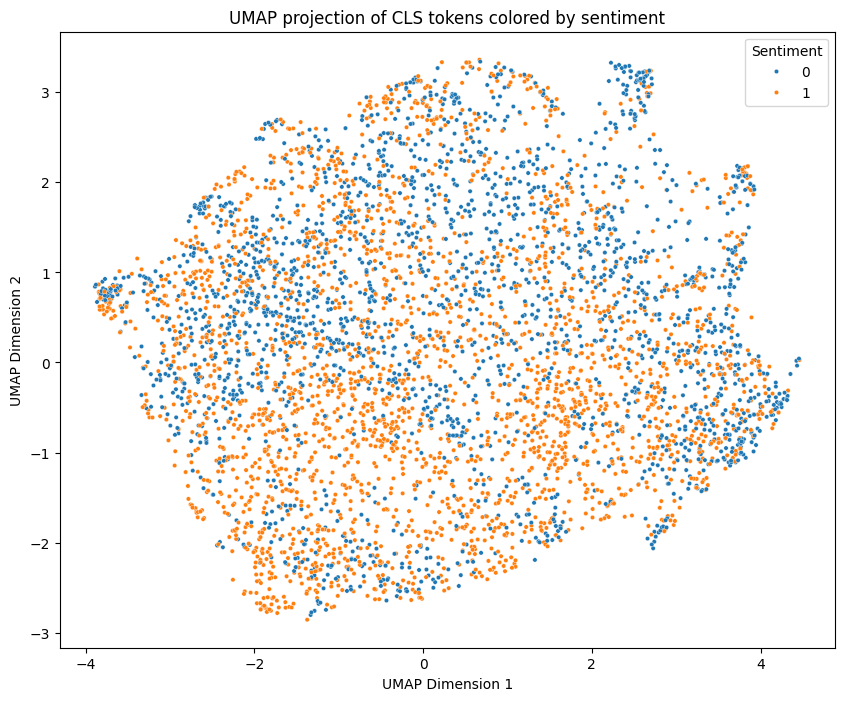

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# UMAP (PCA kimidi amma ferqli cur  dimensionlaty reduction edir, TSNE oxshar edir , amma daha tez , daha duzgun )
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X_train) #2 olchuye saliriq (768-->2)

# DATAFrame yaradirriq
df_viz = pd.DataFrame(embedding, columns=['umap_dim_1', 'umap_dim_2'])
df_viz['label'] = y_train

In [ ]:
df_viz_neg = df_viz[df_viz['label'] == 0]
df_viz_pos = df_viz[df_viz['label'] == 1]


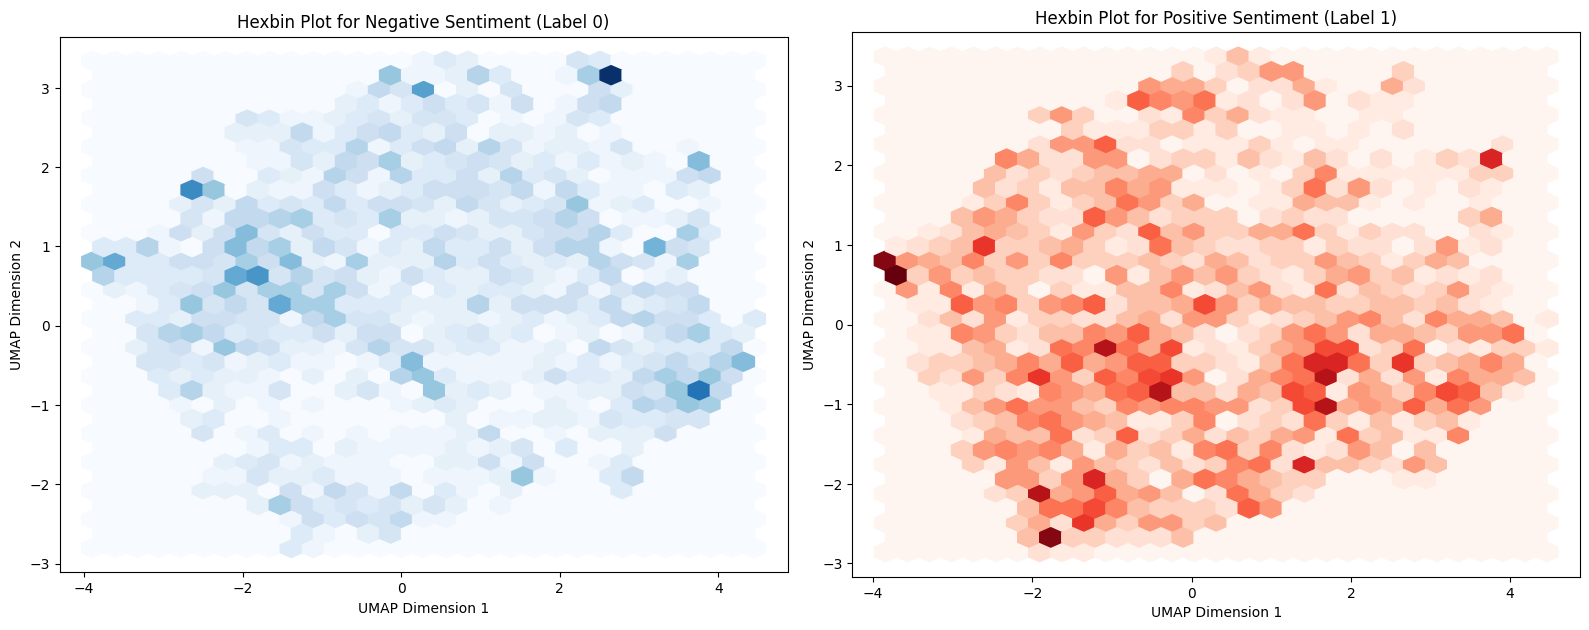

In [ ]:
# suplot duzeldirik
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# negative class (label 0)
axes[0].hexbin(df_viz_neg['umap_dim_1'], df_viz_neg['umap_dim_2'], gridsize=30, cmap='Blues')
axes[0].set_title('Negative Sentiment (Label 0)')
axes[0].set_xlabel('UMAP 1-ci olchu')
axes[0].set_ylabel('UMAP 2-ci olchu')
axes[0].set_aspect('equal', adjustable='box')

#positive class (label 1)
axes[1].hexbin(df_viz_pos['umap_dim_1'], df_viz_pos['umap_dim_2'], gridsize=30, cmap='Reds')
axes[1].set_title('Positive Sentiment (Label 1)')
axes[1].set_xlabel('UMAP 1-ci olchu ')
axes[1].set_ylabel('UMAP  2-ci olchu')
axes[1].set_aspect('equal', adjustable='box')


plt.tight_layout()
plt.show()

###sklearn model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [ ]:
model_sklearn = LogisticRegression(max_iter=1000, solver="liblinear")
model_sklearn.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
print(f'train score:{model_sklearn.score(X_train,y_train)}, val score:{model_sklearn.score(X_val ,y_val)}' )

train score:0.8834, val score:0.8211009174311926


In [ ]:
y_pred = model_sklearn.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.81       428
           1       0.81      0.85      0.83       444

    accuracy                           0.82       872
   macro avg       0.82      0.82      0.82       872
weighted avg       0.82      0.82      0.82       872



### Error analysis

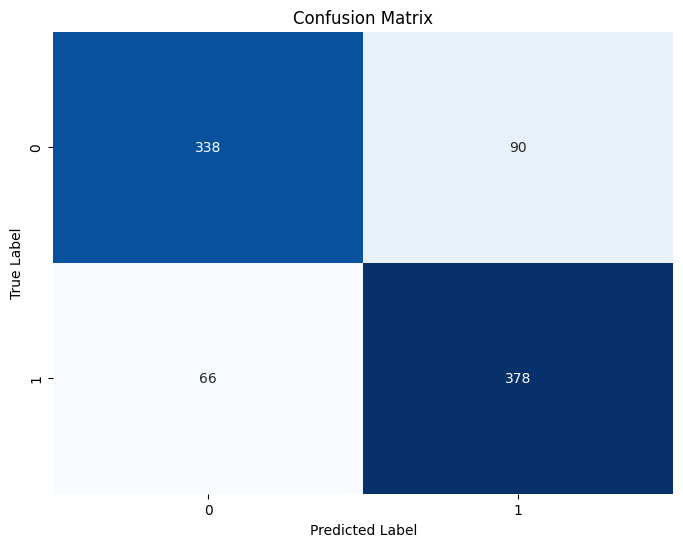

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
encoded['validation'].set_format('pandas')

In [ ]:
df_val=encoded['validation'][:]

In [ ]:
df_val['pred']=y_pred

In [ ]:
df_val_errors = df_val[df_val['label'] != df_val['pred']][['sentence', 'label', 'pred']]
pd.set_option('display.max_colwidth', None)
df_val_errors[:10]

,sentence,label,pred
11,"it takes a strange kind of laziness to waste the talents of robert forster , anne meara , eugene levy , and reginald veljohnson all in the same movie .",0,1
13,"we root for ( clara and paul ) , even like them , though perhaps it 's an emotion closer to pity .",1,0
20,"pumpkin takes an admirable look at the hypocrisy of political correctness , but it does so with such an uneven tone that you never know when humor ends and tragedy begins .",0,1
22,holden caulfield did it better .,0,1
25,"nicks , seemingly uncertain what 's going to make people laugh , runs the gamut from stale parody to raunchy sex gags to formula romantic comedy .",0,1
26,"the action switches between past and present , but the material link is too tenuous to anchor the emotional connections that purport to span a 125-year divide .",0,1
33,"if the movie succeeds in instilling a wary sense of ` there but for the grace of god , ' it is far too self-conscious to draw you deeply into its world .",0,1
37,"( w ) hile long on amiable monkeys and worthy environmentalism , jane goodall 's wild chimpanzees is short on the thrills the oversize medium demands .",0,1
42,the subtle strength of `` elling '' is that it never loses touch with the reality of the grim situation .,1,0
45,it offers little beyond the momentary joys of pretty and weightless intellectual entertainment .,0,1


#Fine-Tune

###Import data/libraries

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#eger GPU varsa GPU ile yoxdursa CPU (device-imiz olsun)
print(f"Using device: {device}")

Using device: cpu


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
from datasets import load_dataset
# "SST-2" datasetini GLUE benchmarkından yükləyirik
# Bu, ən çox istifadə olunan standart versiyasıdır bu task uchun
dataset = load_dataset("glue", "sst2")

###Model

In [ ]:
model_name='distilbert-base-uncased'
model_with_head=AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


bele bir yazi gelmelidi:


```
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
```
bu o demekdir ki , sondaki dense layer (head) random qiymetler ile bashlayir . Biz onu train edeceyik.


In [ ]:
tokenizer=AutoTokenizer.from_pretrained(model_name)

### Metrics

<details>
<summary>📊 <b>NLP Task Metrics - Real nümunələrlə</b> (gizlət/göstər)</summary>

---


<details>
<summary>1️⃣ Classification (F1, Precision, Recall, Accuracy) ✅</summary>

**Cümlələr və etiketlər:**

| Cümlə                  | True Label | Predicted Label |
|------------------------|------------|----------------|
| "I love NLP"           | Positive   | Positive       |
| "I hate bugs"          | Negative   | Positive       |
| "Python is fun"        | Positive   | Positive       |
| "Debugging is hard"    | Negative   | Negative       |

**Hesablanma:**

- True Positives (TP) = 2 (`"I love NLP"`, `"Python is fun"`)  
- False Positives (FP) = 1 (`"I hate bugs"`)  
- False Negatives (FN) = 0  
- Accuracy = (TP + TN) / Total = (2 + 1)/4 = 0.75  
- Precision = TP / (TP + FP) = 2 / (2 + 1) = 0.666  
- Recall = TP / (TP + FN) = 2 / (2 + 0) = 1.0  
- F1 = 2 * (Precision * Recall) / (Precision + Recall) = 0.8  

💡 **İntüitiv:** F1 balans yaradır, səhv pozitivləri və qaçanları nəzərə alır.

</details>

---


<details>
<summary>2️⃣ NER (Token-level & Entity-level F1) 🏷️</summary>

**Cümlə:** "John lives in Paris"  
**True Labels:** `John→B-PER`, `Paris→B-LOC`  
**Predicted Labels:** `John→B-PER`, `Paris→B-LOC`

| Token  | True | Pred  | Result |
|--------|------|-------|--------|
| John   | B-PER | B-PER | ✅      |
| lives  | O    | O     | ✅      |
| in     | O    | O     | ✅      |
| Paris  | B-LOC | B-LOC | ✅     |

- Token-level Accuracy = 4/4 = 1.0  
- Entity-level F1 = 1.0 (hər entity tam düzgün tapıldı)  

💡 **İntüitiv:** Entity-level F1 ardıcıllığı nəzərə alır, tək token-ləri yox, bütün entity-ni dəyərləndirir.

</details>

---


<details>
<summary> 3️⃣ ROUGE (Summarization) 📝</summary>

**Reference Summary:** "John loves Paris."  
**Generated Summary:** "John enjoys Paris."

- ROUGE-1 (unigram overlap): `{John, Paris}` overlap = 2 / 3 ≈ 0.66  
- ROUGE-2 (bigram overlap): `{John loves, loves Paris}` overlap = 0 / 2 = 0.0  
- ROUGE-L (longest common subsequence): `John ... Paris` = 2 / 3 ≈ 0.66  

💡 **İntüitiv:** ROUGE n-gram əsaslı oxşarlığı ölçür, uzun ardıcıllıqları da nəzərə alır.

</details>

---

<details>
<summary> 4️⃣ BLEU (Translation) 🌐</summary>

**Reference:** "The cat is on the mat"  
**Generated:** "The cat sits on the mat"

- Unigram match: `The, cat, on, the, mat` → 5/6 ≈ 0.833  
- Bigram match: `The cat, cat sits, sits on, on the, the mat` → 3/5 = 0.6  
- BLEU score (simplified): 0.7  

💡 **İntüitiv:** BLEU n-gram match + brevity penalti ilə deyir: “Model referans cümləyə nə qədər oxşardır?”

</details>

---


<details>
<summary>5️⃣ METEOR (Translation / Text Generation) 🎯</summary>

**Reference:** "John loves playing football"  
**Generated:** "John enjoys football"

- Exact match = `John, football` = 2  
- Stem match = `loves` ~ `enjoys` → 1  
- METEOR combines exact + stem + synonym = 0.8 (təxminən)  

💡 **İntüitiv:** METEOR yalnız dəqiq match yox, sinonim və lemmatization nəzərə alır.  

</details>

---


<details>
<summary>6️⃣ Transformers Metrics (BERT / GPT və s.) 🤖</summary>

| Model Task        | Çıxış Növü          | Metric Nümunəsi | Hesablama Nümunəsi |
|------------------|-------------------|----------------|------------------|
| BERT Sentiment    | Single Label       | F1             | Classification nümunəsi yuxarıda |
| BERT NER          | Token / Entity     | Entity-F1      | NER nümunəsi yuxarıda |
| GPT / Seq2Seq     | Generated Text     | ROUGE/BLEU/METEOR | Seq2seq nümunələri yuxarıda |

💡 **İntüitiv:** Hər model task-a uyğun metric seçilir, yanlış metric yanıltıcı nəticə verə bilər.

</details>
---
<details>
<summary>🧠 <b>BERT-based Semantic Metrics / Contextual Word Meaning</b> (gizlət/göstər)</summary>

---

1️⃣ Nədir?  
BERT və transformer modelləri hər bir sözü **kontekst əsasında** vektor şəklində təmsil edir. Bu vektorlar sözün **cümlədəki mənasını** daşıyır.  
- Yəni "bank" sözü “river bank” və “money bank” kontekstində fərqli embeddinglərə malikdir.  
- Bu, **semantic similarity**, **word sense disambiguation (WSD)** və **text entailment** kimi tapşırıqlarda istifadə olunur.

---

2️⃣ Nümunə: Word Sense
**Cümlələr:**  
1. "I went to the bank to deposit money."  
2. "He sat by the river bank."  

- BERT embeddingləri ilə hər bir “bank” tokeni **fərqli vektor** alır.  
- Cosine similarity ilə baxsaq:
    - `sim("bank_money", "bank_river") ≈ 0.1` → mənalar fərqlidir  
    - `sim("bank_money", "deposit") ≈ 0.8` → mənalar oxşardır

💡 **İntüitiv:** Model sözü cümlə kontekstinə görə “anlayır”.

---

3️⃣ ROUGE və Semantic-Aware Metrics
- Klassik ROUGE yalnız n-gram uyğunluğunu ölçür.  
- Semantic-aware ROUGE və ya BERTScore:
    - `BERTScore` hər tokeni contextual embedding-ə çevirir.  
    - Generated və Reference cümlə tokenlərinin **embedding similarity** ölçülür.  
    - Bu, daha “insan-məntiqli” keyfiyyət qiyməti verir.

| Metric      | Nə ölçür?                   | Nümunə             |
|------------|-----------------------------|------------------|
| ROUGE-1    | Unigram overlap             | 0.66             |
| ROUGE-L    | Longest common subsequence   | 0.66             |
| BERTScore  | Contextual similarity (F1)  | 0.92             |

💡 **İntüitiv:** Generated summary “oxşar söz” işlədibsə, BERTScore bunu qiymətləndirir, ROUGE isə yox.

---

4️⃣ Kiçik Nümunə
**Reference:** "The cat sat on the mat."  
**Generated:** "The feline is on the rug."

- ROUGE-1 = 2/6 ≈ 0.33 (`The`, `on`)  
- BERTScore = 0.85 → semantic oxşarlıq daha yüksək göstərir  

---

5️⃣ Nəticə
- Klassik n-gram metric-lər → exact match  
- BERT / contextual metric-lər → mənanı nəzərə alır  
- Xüsusilə **summarization**, **translation**, **paraphrasing** tapşırıqlarında istifadə olunur

</details>

</details>


<details>
<summary>📌 <b>Seqeval (NER üçün)(hal hazirkii taska aid deyil, amma ardicilliq vacib olan tasklarda lazimdi)</b> (gizlət/göstər)</summary>

---

1️⃣ Nədir?
`seqeval` kitabxanası **token-level etiketləri** götürərək **entity-level F1, precision və recall** hesablayır.  
- Token-level: Hər token üçün düzgün etiket.  
- Entity-level: Ardıcıl tokenlərdən təşkil olunmuş tam entity düzgün təyin olunubsa sayılır.

---

2️⃣ Nümunə
Cümlə: `"John lives in Paris"`

| Token  | True Label | Predicted Label |
|--------|------------|----------------|
| John   | B-PER      | B-PER          |
| lives  | O          | O              |
| in     | O          | O              |
| Paris  | B-LOC      | B-LOC          |

- **Entity-level F1** = 1.0  
- **Token-level Accuracy** = 4/4 = 1.0

💡 **İntüitiv:** Seqeval yalnız **tam entity-ləri düzgün təyin etməyə** baxır, tək token uyğunsuzluğu F1-ə təsir edir.

---

3️⃣ Kiçik Python nümunəsi

```python
from seqeval.metrics import classification_report, f1_score

y_true = [['B-PER', 'O', 'O', 'B-LOC']]
y_pred = [['B-PER', 'O', 'O', 'B-LOC']]

print(classification_report(y_true, y_pred))
print("Entity-level F1:", f1_score(y_true, y_pred))

           precision    recall  f1-score   support

      LOC       1.00      1.00      1.00       1
      PER       1.00      1.00      1.00       1

micro avg       1.00      1.00      1.00       2
```
- NER tapşırıqlarında ən etibarlı metricdir.
- Token-level uyğunsuzluq entity-level F1-i azalda bilər.
- Seqeval həm BIO/BILOU etiket formatını dəstəkləyir.

</details>


In [ ]:
from sklearn.metrics import precision_recall_fscore_support,accuracy_score

In [ ]:
def computation_metrics(x):
    # Gerçək label-lər
    labels = x.label_ids #➡️ Burada doğru label-lər götürülür/ x.label_ids = test setdəki və ya validation setdəki həqiqi class etiketləri (ground truth).
    #labels = [1, 0, 2, 2, 1]


    # Modelin proqnozu (ən böyük ehtimallı class)
    preds = x.predictions.argmax(-1) #➡️ x.predictions — modelin çıxışıdır (logit-lər, yəni ehtimallar). #argmax(-1) = hər sətirdə ən böyük ehtimalın indeksini seçir.

#bu formada==> #     x.predictions = [
#   [0.1, 0.7, 0.2],  # ehtimallar (class 1 ən böyükdür)
#   [0.8, 0.1, 0.1],  # class 0
#   [0.05, 0.25, 0.7],# class 2
#   ...
# ]
    # Precision, Recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted") #average="weighted" – Class-lar balanssız olanda hər class-ın payını nəzərə alır.
    # Accuracy
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'recall': recall,
        'precision': precision
    }


###LETS TRAIIIIIN !!!!😊😁🎉✨

#### Hugging Face

In [ ]:
#eger hugging face modelinizi yuklemek isteyirsizse ( chekckpoint kimi veya, sonda pipeline ile rahatliqla istifade etmek uchun )
#Hugging Faceden Token elde etmelisiz

In [ ]:
#Hugging face daxil olmaqin 2 genish yayilan usulu var
#1)
#from huggingface_hub import notebook_login
#notebook_login() # <-------------------------------------bura tokeninizi yerleshdirmelisiz

#### Tokenize

In [ ]:
def tokenize(example):
    return tokenizer(example['sentence'], max_length=512, truncation=True, padding="max_length")

In [ ]:
tokenized_dataset=dataset.map(tokenize, batched=True)

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

In [ ]:
# trainimizde coxlu row var, tez computatin uchun 5000 secirik (67 minini yox)
tokenized_dataset['train'] = tokenized_dataset['train'].select(range(5000))

In [ ]:
train_dataset=tokenized_dataset['train']
val_dataset=tokenized_dataset['validation']

####Train

In [ ]:
from transformers import TrainingArguments, Trainer

In [ ]:

train_args = TrainingArguments(
    output_dir='distilbert-seq-cls',
    eval_strategy='epoch',
    logging_steps=50,              # hər 50 stepdə log yazsın
    num_train_epochs=2,
    per_device_train_batch_size=16, # 64 yox, daha kiçik batch
    per_device_eval_batch_size=32,
    learning_rate=2e-5,             # real learning rate
    save_strategy="epoch",          # hər epoch-da checkpoint saxlasın
    fp16=True if torch.cuda.is_available() else False,  # GPU varsa mixed precision
    report_to="none",
    push_to_hub=False# log yazmasın
)

trainer = Trainer(
    model=model_with_head,
    args=train_args,
    compute_metrics=computation_metrics,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
# # Redefine the Trainer with the updated datasets
# trainer = Trainer(model=model_with_head,
#                   args=train_args,
#                   compute_metrics=computation_metrics,
#                   train_dataset=train_dataset,
#                   eval_dataset=val_dataset,
#                   )

# # Now train the model
# trainer.train()